# Pie Charts

DS 2023 | Communicating with Data

## Overview

A pie chart is a circular graph used to display the relative magnitudes of a **numeric** feature associated with a **categorical** feature. 

For example, a categorical feature might be the types of food eaten during a day and the associated numeric feature might be number of calories. 

The entire circle represents sum total of value of a given feature, e.g. the total number of calories consumed in a day.

Each slice represents the contribution to the total by one of the categories. The area of the wedge is proportional to the magnitude of the numeric feature value.

Pie charts use colors to distinguish the different slides.

## Use Cases

Pie charts are good for categorical features that are **parts of some whole**.

- Example include food types and diets, expenses and budgets, or investment options and portfolios.

Additionally, pie charts are good for representing **aggregate** values associated a categorical feature. 

- Each slice must represent a unique value and an associated statistic, such as its count or mean.

The categorical feature values should be **disjoint**, **exhaustive**, and relatively **few** in number.

- Disjoint means that an obseration can have only one category value.

- Exhaustive means that an observation my have one category value.

- The meaning of few in number varies, but the idea is that there should not be so many slices on the pie that they can be distinguished.

## A simple example

Let's create some imaginary data based the already described example &mdash; someone's nutrient consumption in the course of a day by food type and measured in grams.

The **pie** will represent the total number of grams of food consumed by some person in a given day. 

Each **slice** will represent on of the main nutrient groups &mdash; protein, fat, and carbohydrates.

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [61]:
diet = pd.Series({
    'protein': 65,
    'fat': 40,
    'carbs': 18
})

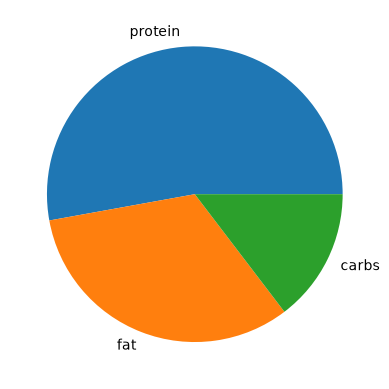

In [62]:
diet.plot.pie()
plt.show()

With this pie chart, we can see clearly the relative amounts consumed from each food type.

The person appears to be on a low-carb diet.

## A more complex example

Let's now look at a classic data set &mdash; the Titanic data set.

This data set shows the survival rate of passengers on the ill-fated vessel that sank in 1912.

It consists entirely of nominal data for $1316$ passengers.

These data are ideal for pie charts because: 

1. Many features contain exhaustive and exclusive labels, e.g. class and sex.
2. The number of values per feature is small.

We can use pie charts to display each feature's composition.

In [63]:
titanic = sns.load_dataset('titanic')
titanic.sample(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
752,0,3,male,33.0,0,0,9.5000,S,Third,man,True,NaN,Southampton,no,True
91,0,3,male,20.0,0,0,7.8542,S,Third,man,True,NaN,Southampton,no,True
214,0,3,male,NaN,1,0,7.7500,Q,Third,man,True,NaN,Queenstown,no,False
392,0,3,male,28.0,2,0,7.9250,S,Third,man,True,NaN,Southampton,no,False
502,0,3,female,NaN,0,0,7.6292,Q,Third,woman,False,NaN,Queenstown,no,True
640,0,3,male,20.0,0,0,7.8542,S,Third,man,True,NaN,Southampton,no,True
613,0,3,male,NaN,0,0,7.7500,Q,Third,man,True,NaN,Queenstown,no,True
845,0,3,male,42.0,0,0,7.5500,S,Third,man,True,NaN,Southampton,no,True
254,0,3,female,41.0,0,2,20.2125,S,Third,woman,False,NaN,Southampton,no,False
302,0,3,male,19.0,0,0,0.0000,S,Third,man,True,NaN,Southampton,no,True


For convenience, let's create a new feature `age_group` based on `age` to show if the person is an adult or child.

In [64]:
titanic['age_group'] = np.where(titanic['age'] >= 18, 'adult', 'child')

In addition, we are only interest in a subset of categorial columns, those that meet the criteria specified above, so we select those.

In [65]:
my_cols = ['sex', 'age_group', 'class','survived']
titanic = titanic[my_cols]
titanic.sample(10)

,sex,age_group,class,survived
641,female,adult,First,1
435,female,child,First,1
880,female,adult,Second,1
659,male,adult,First,0
211,female,adult,Second,1
281,male,adult,Third,0
209,male,adult,First,1
334,female,child,First,1
707,male,adult,First,1
688,male,adult,Third,0


Now let's create a pie chart for each of these features.

To do this, we create a list of **aggregate** data frames, one associated with each feature.

This is necessary because the slices of a pie chart must represent distinct categories.

In [66]:
dfs = {}
for col in my_cols:
    dfs[col] = titanic.value_counts(col)

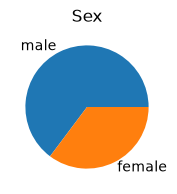

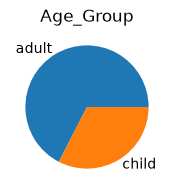

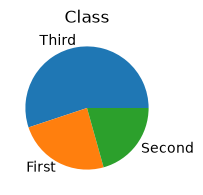

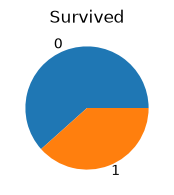

In [67]:
for col in dfs:
    df = dfs[col]
    df.plot.pie(title=col.title(), figsize=(2,2))
    plt.show()

A better way to show all for four pies is with a grid of subplots.

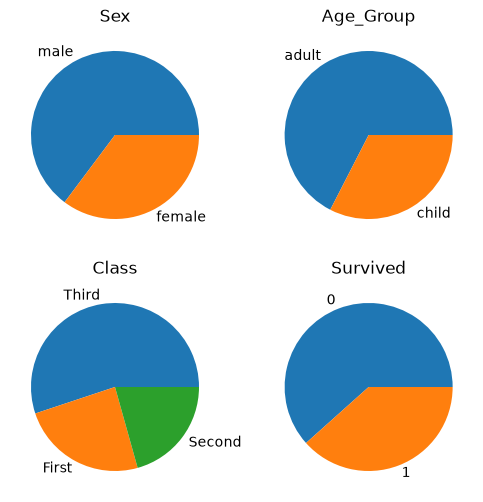

In [68]:
fig, ax = plt.subplots(2, 2, figsize=(6,6))
for i, col in enumerate(titanic.columns):
    c = i % 2
    r = i // 2
    df = titanic.value_counts(col)
    df.plot.pie(title=col.title(), ax=ax[r,c])
plt.show()

## Combining categories

We can see that there are two kinds of features in the Titanic data set: 

- those that define the _category_ of each person

- one that defines the _fate_ each person. 

The first set may be thought of as **input** values and the second as the **output**.

Let's group the data by the category features and get the value counts of the survival feature. 

The produces a data frame where the categorical features form the index and the survival feature is projected onto the column axis.

In [69]:
titanic_vc = titanic[my_cols].value_counts().unstack(fill_value=0)
titanic_vc.columns = ['no','yes']
titanic_vc

no  yes
sex    age_group class           
male   adult     First    61   36
                 Second   82    6
                 Third   182   28
       child     First    16    9
                 Second    9   11
                 Third   118   19
female adult     First     2   75
                 Second    6   56
                 Third    39   28
       child     First     1   16
                 Second    0   14
                 Third    33   44

In this form, the table lets us ask questions like: 

> "If a passenger was a first class adult male, what was their chance of surviving?"

We can use the survival rate data to compute a rough probability estimate `s_rate`  as follows.

In [81]:
titanic_vc['s_rate'] = titanic_vc.div(titanic_vc.sum(axis=1), axis=0).yes
titanic_vc.sort_values('s_rate')

no  yes    s_rate
sex    age_group class                     
male   adult     Second   82    6  0.068129
                 Third   182   28  0.133249
       child     Third   118   19  0.138546
                 First    16    9  0.354961
       adult     First    61   36  0.369725
female adult     Third    39   28  0.415336
male   child     Second    9   11  0.535664
female child     Third    33   44  0.567250
       adult     Second    6   56  0.890440
       child     First     1   16  0.894264
                 Second    0   14  0.937500
       adult     First     2   75  0.962009

Since these data are exhaustive, exclusive, and relatively few, we can use a pie chart to visualize the probabilities.

Note, however, that although the categories are exhaustive and exclusive in this example, the probabilities represented by the pie do not sum to $1$. 

This is because each value is a conditional probability given a combination of categorical features.

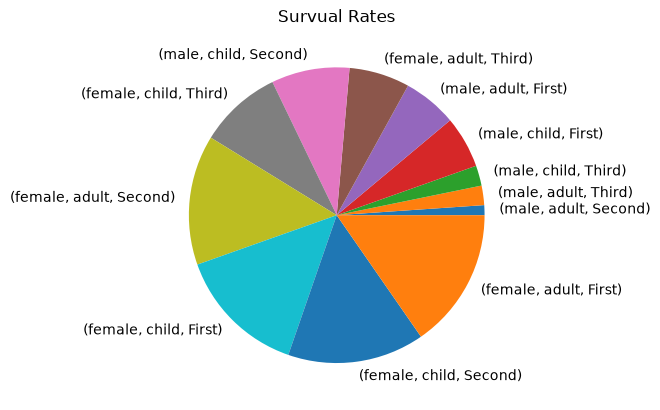

In [84]:
titanic_vc.s_rate.sort_values().plot.pie(title="Survual Rates")
plt.show()

How readable is this chart? Does it easily show which category combinations had the highest and lowest survival rates? 

It turns out that pie charts become less useful as the number of categories increases.

In such cases, it is often better to fall back onto a bar chart.

The one below clearly shows which categories had the highest and lowest survival rates.

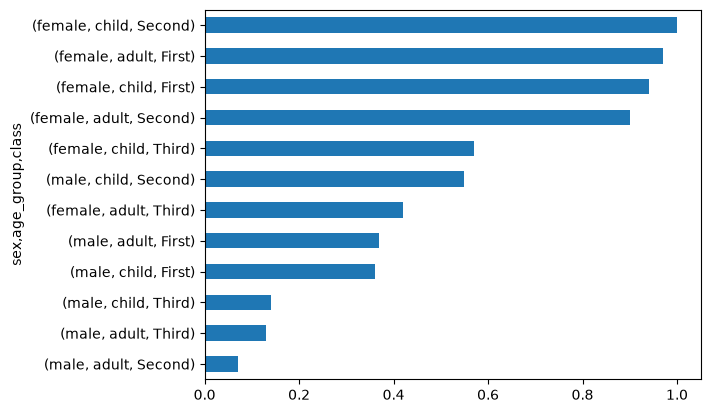

In [13]:
ax = titanic_vc.s_rate.sort_values().plot.barh()
plt.show()

**Note**

Be careful not to read too much into the survival rates of the first and second class children. 

Their total numbers are much smaller than the other categories.

Below, we visualize the fate of the adult passengers.

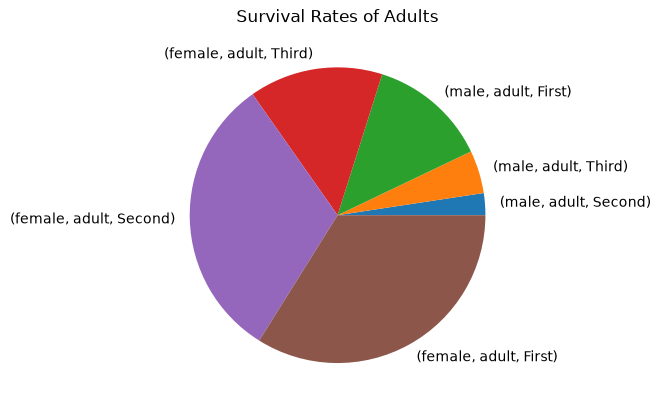

In [92]:
(
    titanic_vc
        .query("age_group == 'adult'")
        .s_rate
        .sort_values()
        .plot
        .pie(title="Survival Rates of Adults")
)
plt.show()

## Improving display

Panda's pie charts come with some useful arguments to improve their display.

These are:

- `autopct`: to label slides with their associated percentages.
- `explode`: to pull out a slide for emphasis.
- `starting`: to orient the pie so that the first cut appears at the degree of your choice.

To use the `autopct` argument, you can pass a standard Python formatting string to autopct to control decimal places.

- `autopct='%1.1f%%'`: Displays one decimal place (e.g., $12.5\%$).
- `autopct='%1.2f%%'`: Displays two decimal places (e.g., $12.50\%$).
- `autopct='%1.0f%%'`: Rounds to the nearest whole integer (e.g., $13\%$)

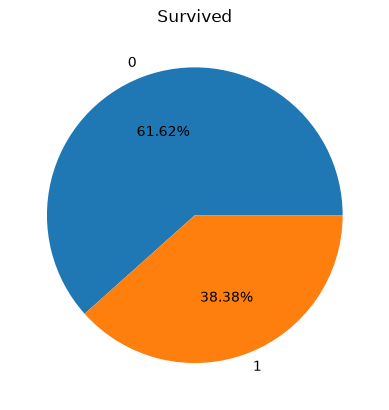

In [96]:
feature_name = 'survived'
dfs[feature_name].plot.pie(autopct='%1.2f%%', title=feature_name.title())
plt.show()

Here's how you can pull out a slide to emphasize it.

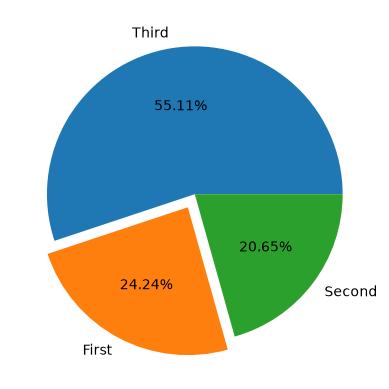

In [108]:
explode_tuple = (0, 0.1, 0) 
dfs['class'].plot.pie(autopct='%1.2f%%', explode=explode_tuple)
plt.show()

Note that you can pull out more than one slice.

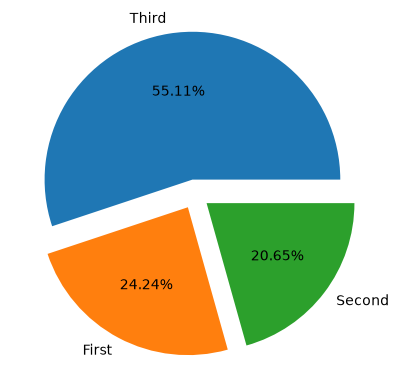

In [107]:
explode_tuple = (0.1, 0.1, 0.1) 
dfs['class'].plot.pie(autopct='%1.2f%%', explode=explode_tuple)
plt.show()

Finally, here's how you can reorient the pie using `startangle`.

Here we set the value to $90\degree$, which corresponses to the <tt>12:00</tt> position of a clock.

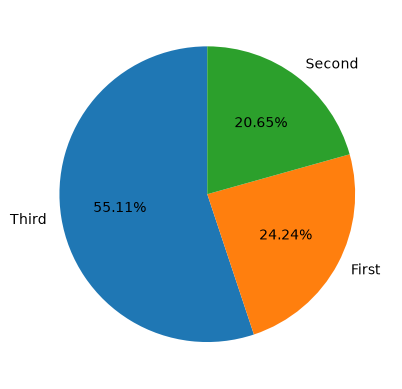

In [106]:
dfs['class'].plot.pie(autopct='%1.2f%%', startangle=90)
plt.show()